# 36 - Batch Normalization

**Section:** Metaparameters | **Prereqs:** `Metaparameters/LossFunctions.ipynb` | **Next:** `Metaparameters/SGDwithMomentum.ipynb`

Scaling the *inputs* helps (`Normalization.ipynb`). Batch normalisation applies
the same idea to every layer's *activations*, continuously, during training.

**What it does.** For each unit, normalise across the batch to zero mean and unit
variance, then apply two learned parameters (a scale and a shift) so the network
can undo the normalisation if it wants to. The layer keeps a running mean and
variance, which is what it uses at eval time - so batch-norm is another layer
whose behaviour depends on `.train()` / `.eval()`.

**Why it helps** - a deeper layer's input distribution shifts every time an
earlier layer updates, so it spends its capacity chasing a moving target.
BatchNorm pins that distribution. In practice it lets you use much larger
learning rates, makes deep networks trainable at all, and adds a little
regularisation for free (each sample's normalisation depends on its batch-mates).

**Where it goes:** `Linear -> BatchNorm -> activation`, and no bias on the Linear
layer (BatchNorm's shift replaces it). Use `BatchNorm1d` after `Linear`,
`BatchNorm2d` after `Conv2d`.

**One trap:** BatchNorm needs more than one sample per batch to compute a
variance. A batch of size 1 in training mode raises.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [26]:
!pip install ucimlrepo

In [27]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

cols = X.columns

In [28]:
# StandardScaler on the inputs. Note that this is INPUT normalisation - batch
# norm below does the same thing to hidden activations. Both are useful; they
# solve the problem at different points in the network.
# X_raw is kept so the model's scaler can be fit on the training split alone;
# what is scaled here is a display copy used by the cells that follow.

X_raw = X.copy()
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [29]:
X = pd.DataFrame(X, columns=(cols))

In [30]:
X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,0.142473,2.188833,-2.192833,-0.744778,0.569958,-1.100140,-1.446359,1.034993,1.813090,0.193097,-0.915464
1,0.451036,3.282235,-2.192833,-0.597640,1.197975,-0.311320,-0.862469,0.701486,-0.115073,0.999579,-0.580068
2,0.451036,2.553300,-1.917553,-0.660699,1.026697,-0.874763,-1.092486,0.768188,0.258120,0.797958,-0.580068
3,3.073817,-0.362438,1.661085,-0.744778,0.541412,-0.762074,-0.986324,1.101694,-0.363868,0.327510,-0.580068
4,0.142473,2.188833,-2.192833,-0.744778,0.569958,-1.100140,-1.446359,1.034993,1.813090,0.193097,-0.915464
...,...,...,...,...,...,...,...,...,...,...,...
6492,-0.783214,-0.787650,-0.197054,-0.807837,-0.486252,-0.367664,-0.420128,-1.186161,0.320319,-0.210144,0.593818
6493,-0.474652,-0.119460,0.284686,0.537425,-0.257883,1.491697,0.924588,0.067824,-0.426067,-0.478971,-0.747766
6494,-0.551792,-0.605417,-0.885253,-0.891916,-0.429160,-0.029599,-0.083949,-0.719251,-1.421248,-0.478971,-0.915464
6495,-1.323198,-0.301694,-0.128234,-0.912936,-0.971538,-0.593041,-0.101642,-2.003251,0.755710,-1.016626,1.935402


In [31]:
# Binarise quality at 5.
# Binarizing the targets

y['Bool Quality'] = y > 5

/tmp/ipython-input-31-2592541463.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['Bool Quality'] = y > 5


In [32]:
y['Bool Quality'] = y['Bool Quality'].astype(int)

/tmp/ipython-input-32-10765186.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['Bool Quality'] = y['Bool Quality'].astype(int)


In [33]:
y = y.drop('quality', axis=1)

In [34]:
y

,Bool Quality
0,0
1,0
2,0
3,1
4,0
...,...
6492,1
6493,0
6494,1
6495,1


In [35]:
# Split the RAW features, then fit the scaler on the training half only.
model_scaler = StandardScaler()
X_train, X_test, Y_train, Y_test = train_test_split(X_raw.to_numpy(), y.to_numpy(), test_size=0.20)

X_train = torch.tensor(model_scaler.fit_transform(X_train), dtype=torch.float, device="cuda")
X_test  = torch.tensor(model_scaler.transform(X_test),      dtype=torch.float, device="cuda")
Y_train = torch.tensor(Y_train, dtype=torch.float, device="cuda")
Y_test  = torch.tensor(Y_test,  dtype=torch.float, device="cuda")

train_data = TensorDataset(X_train, Y_train)
test_data = TensorDataset(X_test,Y_test)

bs = 32
train_loader = DataLoader(train_data, batch_size=bs, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [36]:
# The model with a BatchNorm1d after every Linear layer, and a flag to switch
# them off - the whole experiment in one class.
# Order here is Linear -> BatchNorm -> ReLU, the standard placement.
# BatchNorm1d(128) takes the FEATURE count, and normalises each of those 128
# units across the samples in the batch.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(11,128)
    self.bnorm0 = nn.BatchNorm1d(128)

    self.fc1 = nn.Linear(128,128)
    self.bnorm1 = nn.BatchNorm1d(128)

    self.fc2 = nn.Linear(128,128)
    self.bnorm2 = nn.BatchNorm1d(128)

    self.output_layer = nn.Linear(128,1)

  def forward(self,x,BNBool):

    if BNBool:
      x = F.relu(self.bnorm0(self.input_layer(x)))
      x = F.relu(self.bnorm1(self.fc1(x)))
      x = F.relu(self.bnorm2(self.fc2(x)))
    else:
      x = F.relu(self.input_layer(x))
      x = F.relu(self.fc1(x))
      x = F.relu(self.fc2(x))

    return self.output_layer(x)

In [39]:
# Training function taking the flag. 5000 epochs, SGD at lr=0.001 - deliberately
# a low learning rate, which is where batch norm's advantage is smallest.
def train_model(BNBool):
  lossFunc = nn.BCEWithLogitsLoss()

  WineClassifier = model()
  WineClassifier.to("cuda")

  lr = 0.001
  optimizer = torch.optim.SGD(WineClassifier.parameters(), lr = lr)

  epochs = 5000

  losses = torch.zeros(epochs)
  train_acc = []
  test_acc =[]

  for epoch in range(epochs):

    WineClassifier.train()
    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = WineClassifier.forward(x,BNBool)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100* torch.mean( ((yhat > 0) == y ).float() ).item() )

    train_acc.append(np.mean(batch_acc))
    losses[epoch] = np.mean(batch_loss)

    if (epoch % 100 == 0) :
      print(f"Batch Norm = {BNBool} : Losses = {losses[epoch].item()}")

    WineClassifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      preds = WineClassifier.forward(X,BNBool)
      test_acc.append( 100 * torch.mean( ((preds > 0 ) == Y).float() ) )
  print()
  return losses, train_acc, test_acc


In [40]:
# The comparison: identical models, identical data, batch norm on and off.
BNlosses, BNtrain_acc, BNtest_acc = train_model(True)

losses, train_acc, test_acc = train_model(False)

Batch Norm = True : Losses = 0.6596229076385498
Batch Norm = True : Losses = 0.44308361411094666
Batch Norm = True : Losses = 0.39436236023902893
Batch Norm = True : Losses = 0.35793960094451904
Batch Norm = True : Losses = 0.32151976227760315
Batch Norm = True : Losses = 0.30148229002952576
Batch Norm = True : Losses = 0.2677680552005768
Batch Norm = True : Losses = 0.2611486315727234
Batch Norm = True : Losses = 0.23746898770332336
Batch Norm = True : Losses = 0.2280573546886444
Batch Norm = True : Losses = 0.22132156789302826
Batch Norm = True : Losses = 0.20136873424053192
Batch Norm = True : Losses = 0.19763994216918945
Batch Norm = True : Losses = 0.1899663656949997
Batch Norm = True : Losses = 0.18459028005599976
Batch Norm = True : Losses = 0.16878730058670044
Batch Norm = True : Losses = 0.15600788593292236
Batch Norm = True : Losses = 0.17010098695755005
Batch Norm = True : Losses = 0.15258465707302094
Batch Norm = True : Losses = 0.15350636839866638
Batch Norm = True : Losse

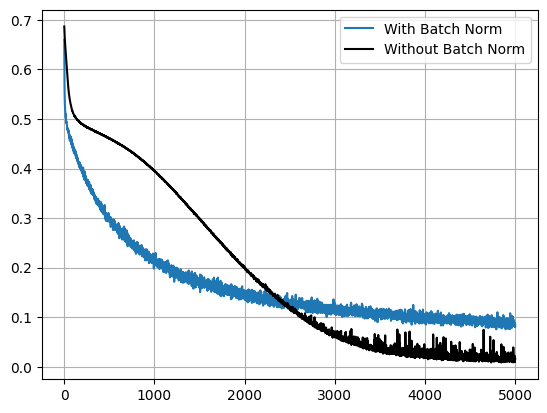

In [41]:
# Loss curves. The batch-norm run should fall faster and end lower.
plt.plot(BNlosses.detach(), "-", label="With Batch Norm")
plt.plot(losses.detach(), 'k-' , label="Without Batch Norm")
plt.grid()
plt.legend();

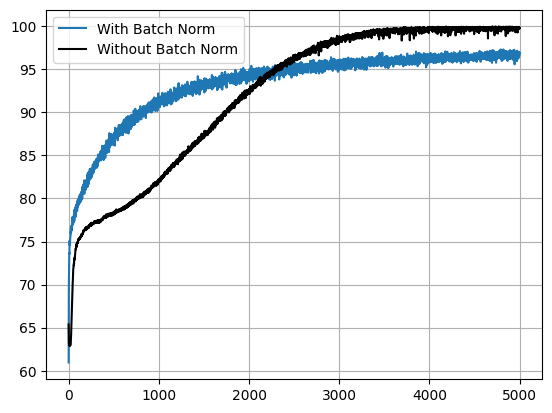

In [42]:
# Train accuracy - same story.
plt.plot(BNtrain_acc, "-", label="With Batch Norm")
plt.plot(train_acc, 'k-' , label="Without Batch Norm")
plt.grid()
plt.legend();

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

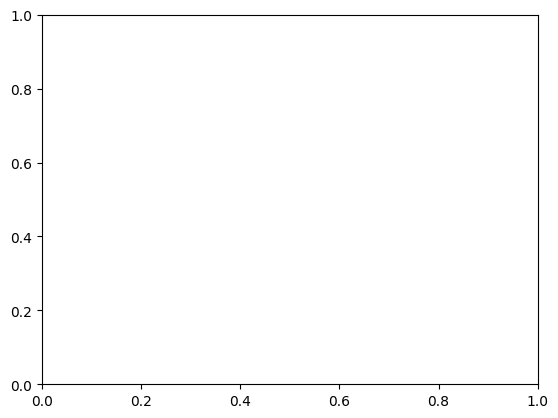

In [53]:
# Test accuracy, the honest comparison.
# List comprehensions, not `for i in xs: i = i.item()` - rebinding the loop
# variable changes nothing about the list.
BNtest_acc = [i.item() for i in BNtest_acc]
test_acc   = [i.item() for i in test_acc]

plt.plot(BNtest_acc, "--", label="With Batch Norm")
plt.plot(test_acc, '-' , label="Without Batch Norm")
plt.grid()
plt.legend();


In [46]:
# Final numbers. Expect a modest gain here - this network is only 3 layers deep.
# BatchNorm's real value shows up in the deep CNNs later in the course, where it
# is often the difference between training and not training at all.
BNtest_acc[-1], test_acc[-1]

(tensor(81.9231, device='cuda:0'), tensor(80.8462, device='cuda:0'))